In [1]:
# 1. Imports
import sys
import os
import pandas as pd
from IPython.display import display

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, econometrics, config

target_volatility = 'Sq_Log_Return'

macro_shocks = ['CPI_Surprise', 'PPI_Surprise', 'FedFunds_Diff'] # The Inflation & Policy Block
# macro_shocks = ['Unemployment_Surprise', 'Housing_Starts_Surprise'] # The Real Economy Block
# macro_shocks = ['Trade_Balance_Surprise', 'M1_Money_Surprise'] # The Global & Liquidity Block

raw_data_dict = data_loader.fetch_raw_data()

# Dictionaries to store our multi-sector results
sector_models = {}
sector_stats = {}
sector_var_data = {}

2026-06-09 15:23:22 - src.data_loader - INFO - Configuration matches cache. Loading data from disk...


In [5]:
# 2. Multi-Sector Processing Loop
for etf in config.TARGET_ETFS:
    print(f"\n" + "="*50)
    print(f"PROCESSING SECTOR: {etf}")
    print("="*50)
    
    # Engineer Features
    raw_df = raw_data_dict[etf]
    stat_df = features.engineer_stationary_features(raw_df, etf_name=etf)
    
    # Prepare VAR Data
    var_data = econometrics.prepare_var_data(stat_df, target_vol_col=target_volatility, macro_cols=macro_shocks)
    sector_var_data[etf] = var_data
    
    # Granger Causality
    econometrics.test_granger_causality(var_data, sector_name=etf, max_lag=5)
    
    # Fit VAR Model (Only printing AIC table for the first ETF to save space)
    print(f"\nFitting VAR Model for {etf}...")
    is_first = (etf == config.TARGET_ETFS[0])
    results, optimal_lag = econometrics.fit_var_model(var_data, max_lags=9, verbose=is_first)
    
    sector_models[etf] = results
    
    # Extract Equation Stats
    stats_df = econometrics.get_equation_stats(results, target_vol_col=target_volatility)
    sector_stats[etf] = stats_df


2026-06-09 15:24:05 - src.features - INFO - Engineering features and macro surprises for XLK...
2026-06-09 15:24:05 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLK

--- Granger Causality: Macro -> XLK ---
[CPI_Surprise]
  Lag 1: p-value = 0.0472 **
  Lag 2: p-value = 0.3190 
  Lag 3: p-value = 0.6157 
  Lag 4: p-value = 0.8711 
  Lag 5: p-value = 0.9459 
[PPI_Surprise]
  Lag 1: p-value = 0.0001 ***
  Lag 2: p-value = 0.0096 ***
  Lag 3: p-value = 0.0546 *
  Lag 4: p-value = 0.2150 
  Lag 5: p-value = 0.5165 
[FedFunds_Diff]
  Lag 1: p-value = 0.0180 **
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0001 ***
  Lag 4: p-value = 0.0002 ***
  Lag 5: p-value = 0.0002 ***

Fitting VAR Model for XLK...

LAG SELECTION CRITERIA
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -19.35      -19.34   3.957e-09      -19.35
1      -24.50      -24.48   2.281e-11      -24.50
2      -25.24     -25.20*   1.098e-11      -25.22
3      -25.24      -25.18   1.093e-11      -25.22
4      -25.25      -25.18   1.081e-11      -25.23
5      

2026-06-09 15:24:07 - src.features - INFO - Engineering features and macro surprises for XLE...
2026-06-09 15:24:07 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLE

--- Granger Causality: Macro -> XLE ---
[CPI_Surprise]
  Lag 1: p-value = 0.0117 **
  Lag 2: p-value = 0.0217 **
  Lag 3: p-value = 0.0824 *
  Lag 4: p-value = 0.3251 
  Lag 5: p-value = 0.5165 
[PPI_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0008 ***
  Lag 4: p-value = 0.0209 **
  Lag 5: p-value = 0.1374 
[FedFunds_Diff]
  Lag 1: p-value = 0.9800 
  Lag 2: p-value = 0.2407 
  Lag 3: p-value = 0.5519 
  Lag 4: p-value = 0.3756 
  Lag 5: p-value = 0.0052 ***

Fitting VAR Model for XLE...


2026-06-09 15:24:09 - src.features - INFO - Engineering features and macro surprises for XLF...
2026-06-09 15:24:09 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLF

--- Granger Causality: Macro -> XLF ---
[CPI_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0000 ***
  Lag 4: p-value = 0.0000 ***
  Lag 5: p-value = 0.0000 ***
[PPI_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0000 ***
  Lag 4: p-value = 0.0000 ***
  Lag 5: p-value = 0.0000 ***
[FedFunds_Diff]
  Lag 1: p-value = 0.3614 
  Lag 2: p-value = 0.1932 
  Lag 3: p-value = 0.0509 *
  Lag 4: p-value = 0.4029 
  Lag 5: p-value = 0.0915 *

Fitting VAR Model for XLF...


2026-06-09 15:24:10 - src.features - INFO - Engineering features and macro surprises for XLV...
2026-06-09 15:24:10 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLV

--- Granger Causality: Macro -> XLV ---
[CPI_Surprise]
  Lag 1: p-value = 0.0810 *
  Lag 2: p-value = 0.4655 
  Lag 3: p-value = 0.5078 
  Lag 4: p-value = 0.6571 
  Lag 5: p-value = 0.8601 
[PPI_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0413 **
  Lag 3: p-value = 0.0676 *
  Lag 4: p-value = 0.1196 
  Lag 5: p-value = 0.3078 
[FedFunds_Diff]
  Lag 1: p-value = 0.1176 
  Lag 2: p-value = 0.0009 ***
  Lag 3: p-value = 0.0055 ***
  Lag 4: p-value = 0.0136 **
  Lag 5: p-value = 0.0001 ***

Fitting VAR Model for XLV...


In [6]:
# 3. SIDE-BY-SIDE EQUATION COMPARISON
print("\n" + "="*80)
print("MULTI-SECTOR VAR EQUATION COMPARISON")
print("="*80)
# This magical pandas function stitches all the sector tables together side-by-side
combined_stats = pd.concat(sector_stats.values(), axis=1, keys=sector_stats.keys())
display(combined_stats.fillna('-'))


MULTI-SECTOR VAR EQUATION COMPARISON


XLK                  XLE                  XLF          \
                    Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   P-Val   
const             0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001  0.0000   
L1.CPI_Surprise  -0.0000  0.5529       0.0001  0.3013       0.0003  0.0045   
L1.PPI_Surprise  -0.0000  0.9246      -0.0000  0.7447      -0.0000  0.1098   
L1.FedFunds_Diff -0.0001  0.3986       0.0004  0.1830       0.0004  0.1257   
L1.Sq_Log_Return  0.1438  0.0000  *** -0.0060  0.6321       0.1358  0.0000   
L2.CPI_Surprise   0.0001  0.5122      -0.0002  0.1105      -0.0002  0.0730   
L2.PPI_Surprise   0.0000  0.6480       0.0000  0.7906       0.0000  0.7615   
L2.FedFunds_Diff -0.0007  0.0001  *** -0.0003  0.2187      -0.0001  0.6101   
L2.Sq_Log_Return  0.1394  0.0000  ***  0.1462  0.0000  ***  0.0917  0.0000   
L3.CPI_Surprise  -0.0001  0.4680       0.0001  0.5754      -0.0000  0.8447   
L3.PPI_Surprise  -0.0000  0.3748       0.0000  0.5275       0.0000  0.6984   
L3.FedFunds_Diff  0.0002  0.3865       0.0003  0.3009      -0.0004  0.1404   
L3.Sq_Log_Return  0.0195  0.1238       0.0942  0.0000  ***  0.0429  0.0007   
L4.CPI_Surprise   0.0000  0.6187       0.0000  0.9539      -0.0000  0.8233   
L4.PPI_Surprise   0.0000  0.4281      -0.0000  0.6397      -0.0000  0.8662   
L4.FedFunds_Diff  0.0001  0.4842       0.0001  0.6259       0.0002  0.4104   
L4.Sq_Log_Return  0.0756  0.0000  ***  0.1696  0.0000  ***  0.0941  0.0000   
L5.CPI_Surprise   0.0000  0.8907       0.0000  0.8960      -0.0001  0.6477   
L5.PPI_Surprise  -0.0000  0.8327      -0.0000  0.8689       0.0000  0.8223   
L5.FedFunds_Diff -0.0002  0.1817      -0.0010  0.0001  *** -0.0004  0.2098   
L5.Sq_Log_Return  0.0776  0.0000  ***  0.1636  0.0000  ***  0.0547  0.0000   
L6.CPI_Surprise  -0.0001  0.5113       0.0001  0.5909       0.0001  0.4071   
L6.PPI_Surprise   0.0000  0.9784       0.0000  0.9750       0.0000  0.5294   
L6.FedFunds_Diff  0.0008  0.0000  ***  0.0001  0.7772       0.0002  0.5626   
L6.Sq_Log_Return  0.0976  0.0000  ***  0.0362  0.0038  ***  0.1945  0.0000   
L7.CPI_Surprise   0.0000  0.6314      -0.0000  0.8204      -0.0000  0.6976   
L7.PPI_Surprise  -0.0000  0.8741      -0.0000  0.5868      -0.0001  0.3342   
L7.FedFunds_Diff -0.0008  0.0000  *** -0.0006  0.0341   ** -0.0001  0.6960   
L7.Sq_Log_Return  0.0063  0.6206       0.1654  0.0000  ***  0.0601  0.0000   
L8.CPI_Surprise   0.0000  0.9967      -0.0001  0.5870       0.0001  0.6151   
L8.PPI_Surprise   0.0000  0.8556       0.0000  0.8142       0.0000  0.9286   
L8.FedFunds_Diff  0.0001  0.6148       0.0000  0.9093       0.0001  0.6375   
L8.Sq_Log_Return  0.1010  0.0000  ***  0.0097  0.4403      -0.0024  0.8491   
L9.CPI_Surprise   0.0000  0.7698       0.0001  0.2984      -0.0000  0.5948   
L9.PPI_Surprise  -0.0000  0.6417      -0.0000  0.7166      -0.0000  0.6480   
L9.FedFunds_Diff -0.0001  0.7538      -0.0010  0.0002  *** -0.0003  0.3135   
L9.Sq_Log_Return  0.0397  0.0016  *** -0.0468  0.0002  ***  0.0782  0.0000   

                          XLV               
                  Sig    Coef   P-Val  Sig  
const             ***  0.0000  0.0000  ***  
L1.CPI_Surprise   *** -0.0000  0.8475       
L1.PPI_Surprise       -0.0000  0.5112       
L1.FedFunds_Diff       0.0000  0.8302       
L1.Sq_Log_Return  ***  0.1386  0.0000  ***  
L2.CPI_Surprise     *  0.0000  0.3294       
L2.PPI_Surprise        0.0000  0.2712       
L2.FedFunds_Diff      -0.0003  0.0009  ***  
L2.Sq_Log_Return  ***  0.3495  0.0000  ***  
L3.CPI_Surprise       -0.0000  0.2384       
L3.PPI_Surprise       -0.0000  0.2076       
L3.FedFunds_Diff       0.0001  0.3183       
L3.Sq_Log_Return  ***  0.0585  0.0000  ***  
L4.CPI_Surprise       -0.0000  0.8962       
L4.PPI_Surprise        0.0000  0.4857       
L4.FedFunds_Diff       0.0000  0.9582       
L4.Sq_Log_Return  *** -0.0405  0.0023  ***  
L5.CPI_Surprise        0.0000  0.6113       
L5.PPI_Surprise        0.0000  0.6939       
L5.FedFunds_Diff      -0.0003  0.


VISUAL DIAGNOSTICS: XLK


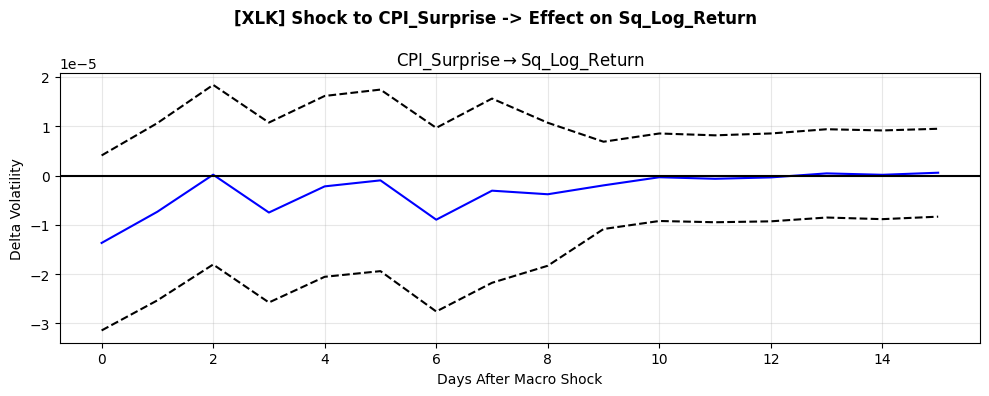

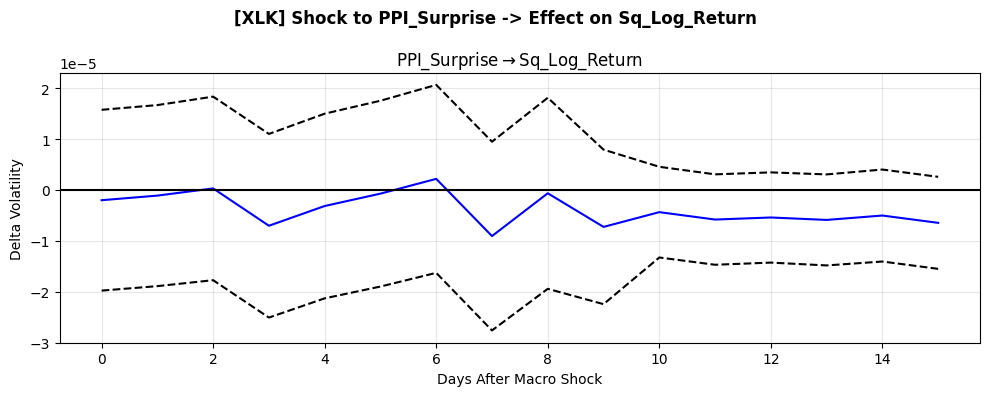

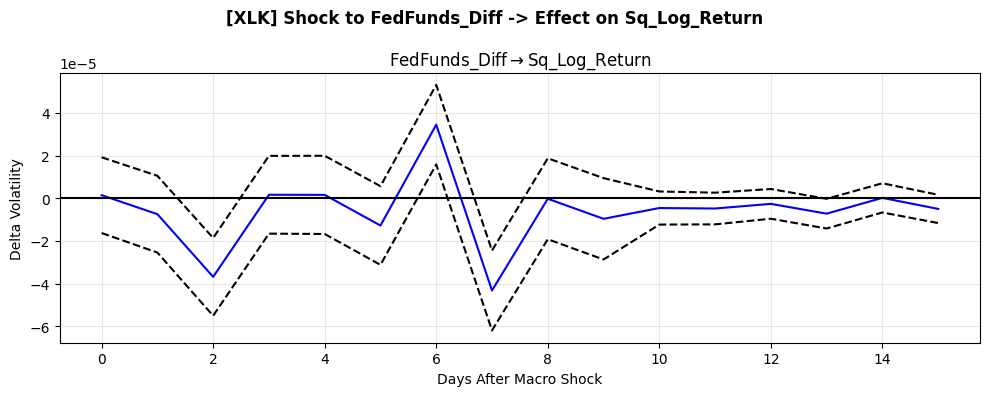

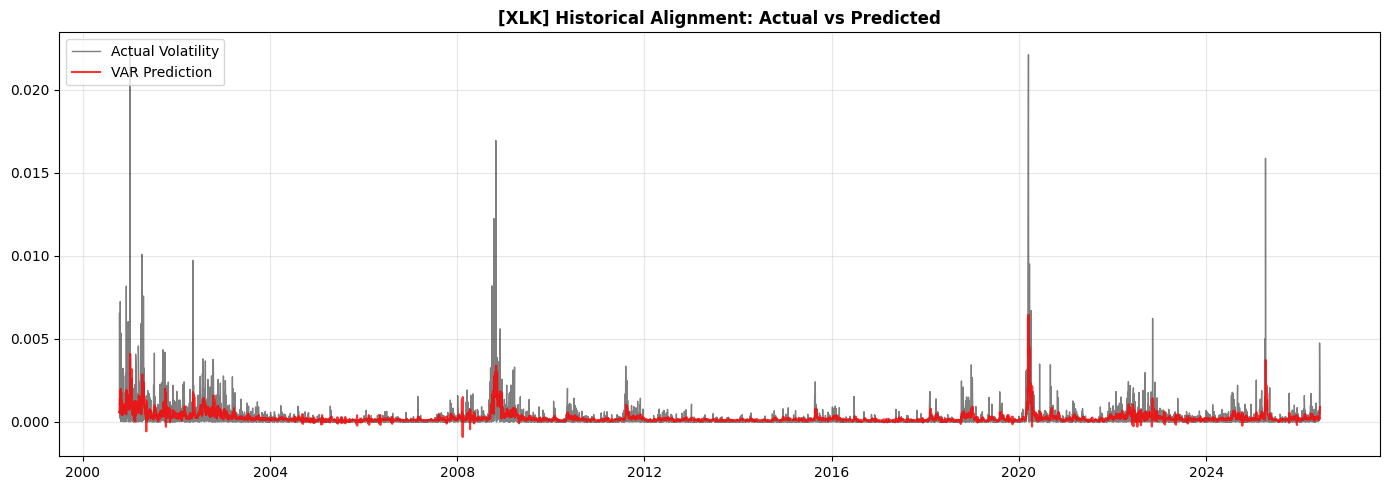


VISUAL DIAGNOSTICS: XLE


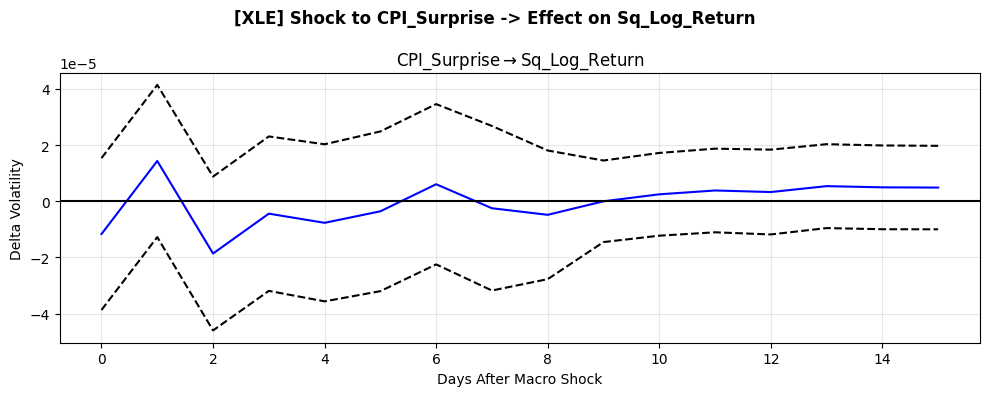

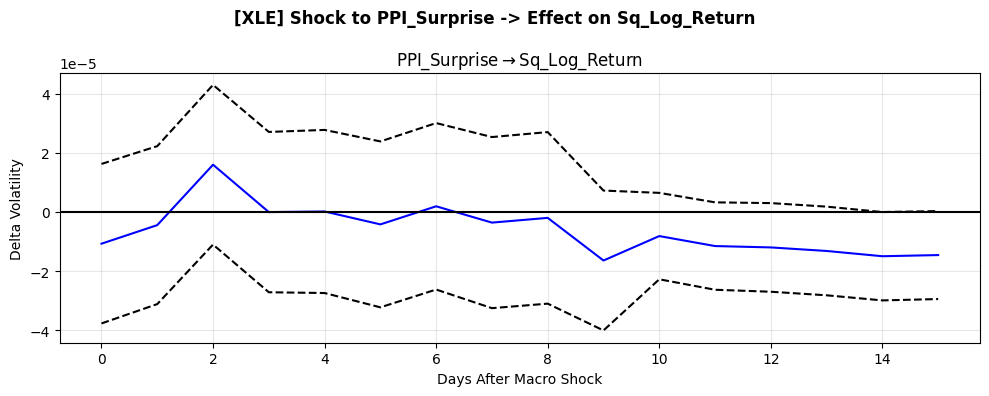

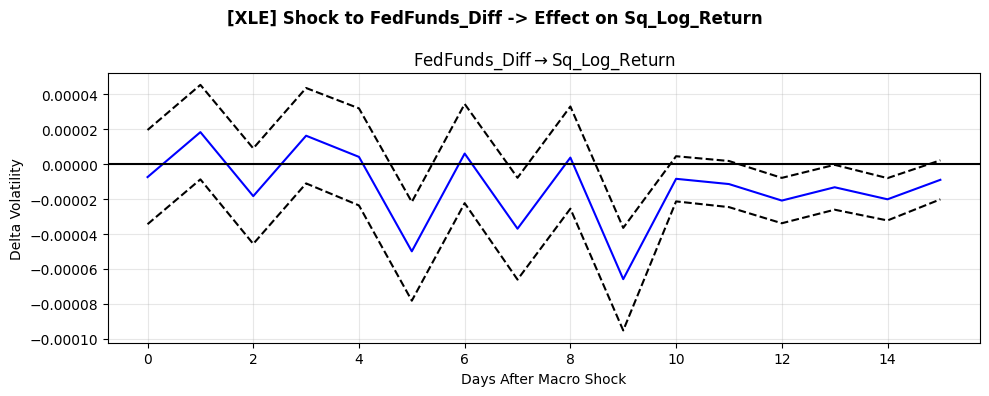

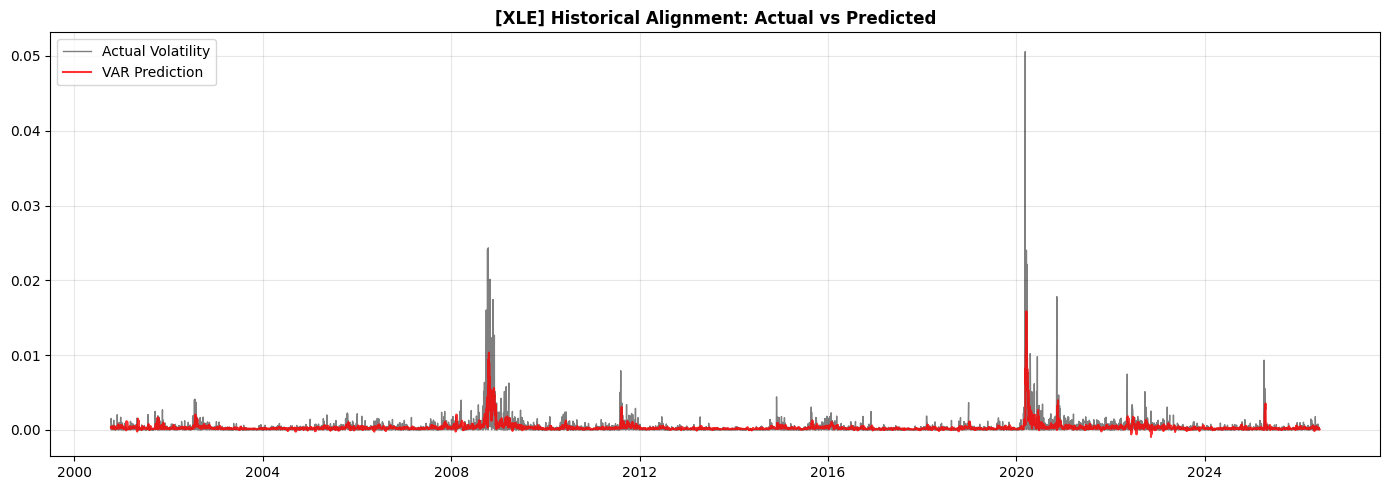


VISUAL DIAGNOSTICS: XLF


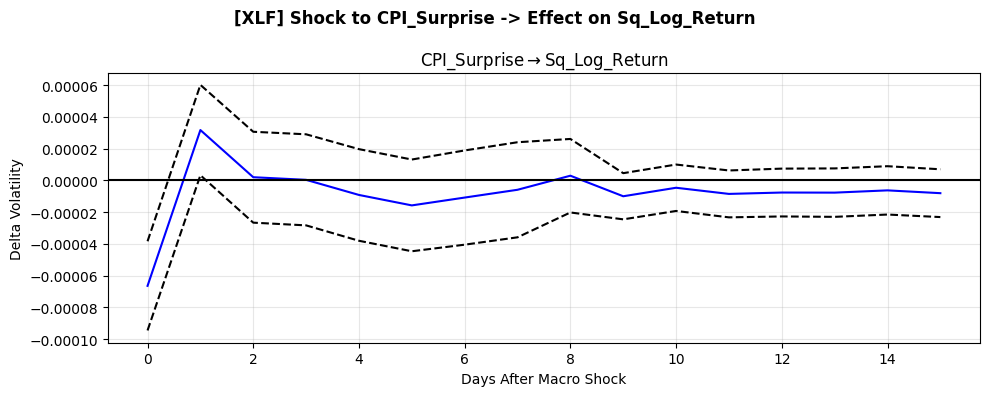

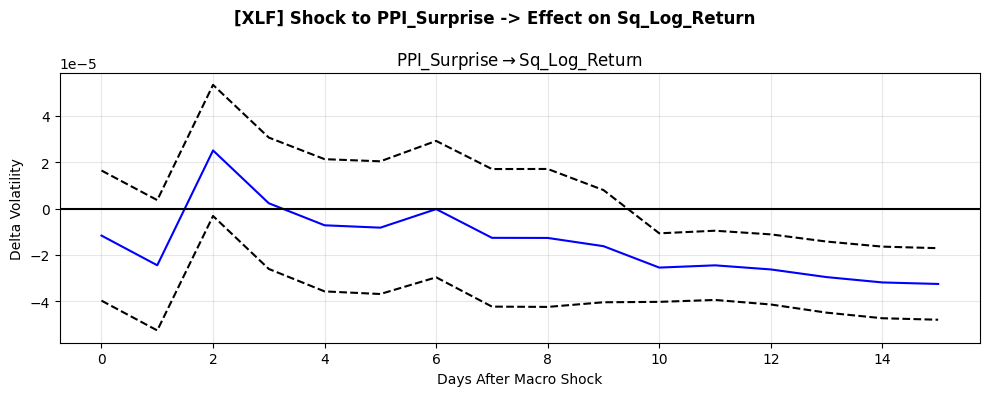

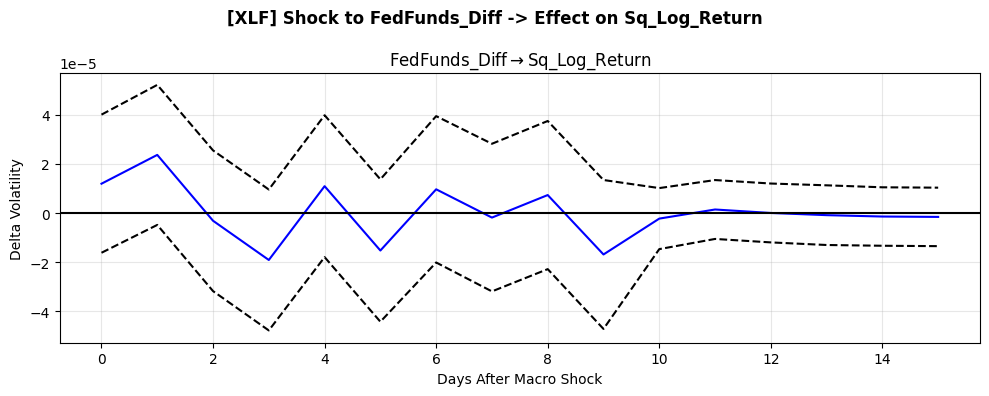

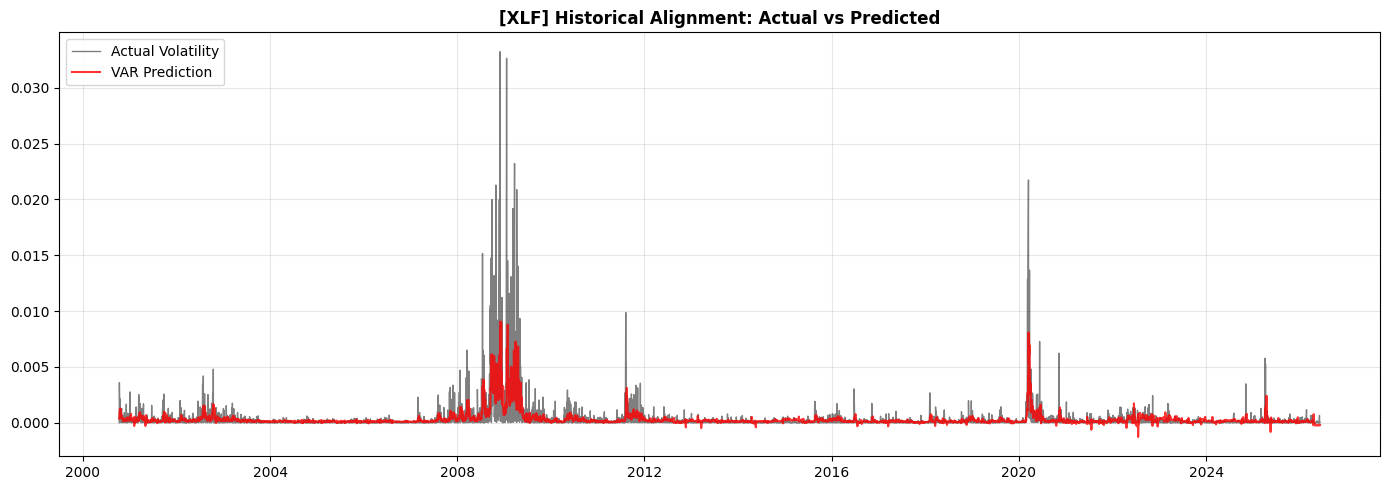


VISUAL DIAGNOSTICS: XLV


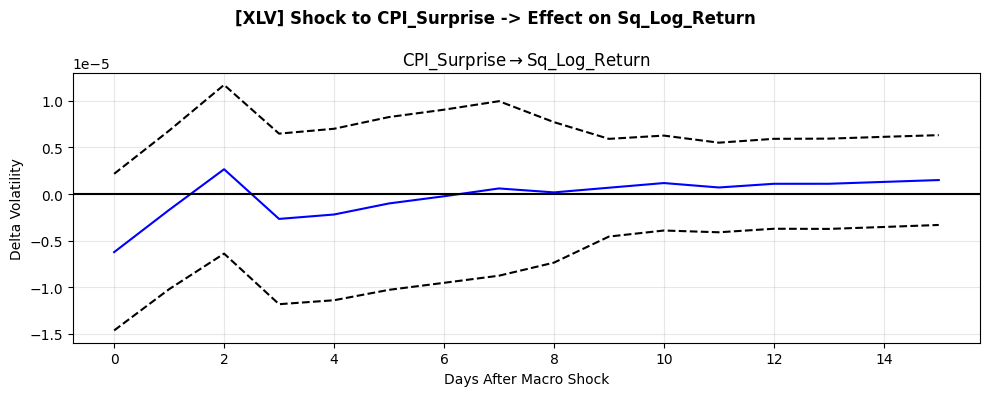

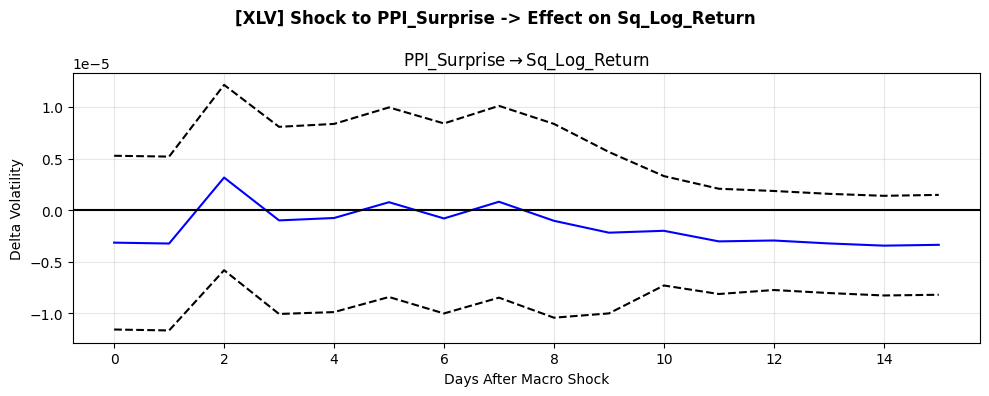

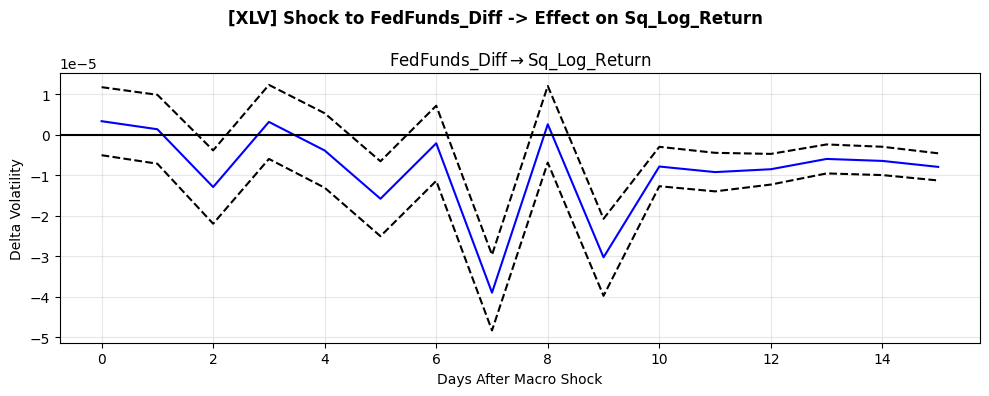

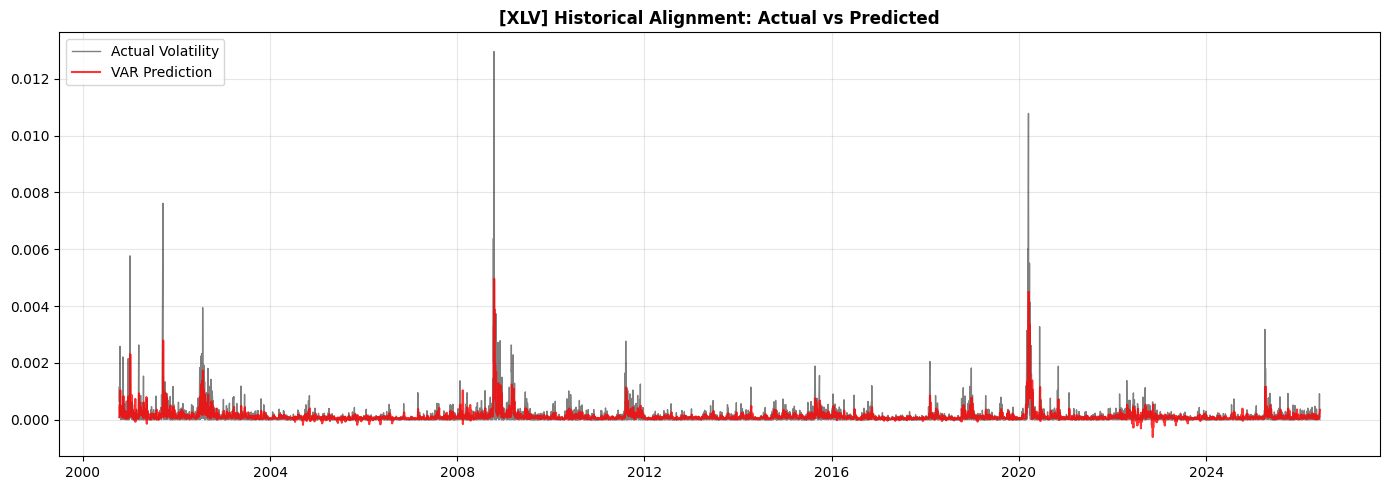

In [7]:
# 4. VISUALIZATIONS
for etf in config.TARGET_ETFS:
    print("\n" + "="*80)
    print(f"VISUAL DIAGNOSTICS: {etf}")
    print("="*80)
    
    results = sector_models[etf]
    var_data = sector_var_data[etf]
    
    econometrics.plot_irfs(results, var_data, sector_name=etf, irf_periods=15)
    econometrics.plot_historical_fit(results, var_data, sector_name=etf)
